<div style="display: flex; align-items: center;">
    <img src="https://github.com/nagelt/Teaching_Scripts/raw/9d9e29ecca4b04eaf7397938eacbf116d37ddc93/Images/TUBAF_Logo_blau.png"
         width="500" height="auto" style="margin-right: 100px;" />
    <div>
        <p><strong>Prof. Dr. Thomas Nagel</strong></p>
        <p>
            Chair of Soil Mechanics and Foundation Engineering<br>
            Geotechnical Institute<br>
            Technische Universität Bergakademie Freiberg.
        </p>
        <p>
            <a href="https://tu-freiberg.de/en/soilmechanics">
                https://tu-freiberg.de/en/soilmechanics
            </a>
        </p>
    </div>
</div>

<div style="display: flex; align-items: center;">
    <p style="margin-top: 1em;">
        To activate the <strong>interactive features</strong> when in nbviewer mode, click on &quot;Execute on Binder&quot;
        <img src="https://mybinder.org/static/favicon.ico"
             alt="Binder"
             style="height: 1.1em; vertical-align: middle; margin: 0 6px;">
        on the top right. Then, click on Run → Run All Cells.
    </p>
</div>


# EQU-Nachweis gegen Kippen und Bettungsmodulverfahren mit zugfreien Federn

## Grenzzustand des Verlusts der Lagesicherheit (EQU) fuer starre Streifenfundamente

In [31]:
import numpy as np #numerical methods
import matplotlib.pyplot as plt #plotting

#Some plot settings
import plot_functions.plot_settings
%run plot_functions/Kippnachweis_plots.ipynb

## 1. Rahmen: Kippen als Grenzzustand des Verlusts der Lagesicherheit (EQU)

Wir betrachten ein **starres Streifenfundament** der Breite $a$ (Laengsrichtung als Einheitsbreite $b=1$ je laufendem Meter), das durch eine resultierende Vertikallast $V$ mit Exzentrizitaet $e_x$ zum Schwerpunkt der Sohlflaeche belastet wird. Eine solche Exzentrizitaet entsteht z.B. aus der Kombination einer zentrischen Normalkraft mit einem Kippmoment $M$ (etwa infolge einer Horizontallast $H$ in der Hoehe $h$ ueber der Sohlfuge):

$$
    e_x = \frac{M}{V}
$$

Wird $e_x$ immer groesser, wandert der Angriffspunkt der Resultierenden in Richtung einer Fundamentkante. Der **EQU-Grenzzustand "Kippen"** ist erreicht, wenn die Resultierende die Kante der Sohlflaeche erreicht ($|e_x| = a/2$): Fuer jede groessere Exzentrizitaet laesst sich keine Sohldruckverteilung mehr finden, die ausschliesslich aus Druckspannungen besteht und gleichzeitig Kraefte- und Momentengleichgewicht erfuellt -- das Fundament verliert die Gleichgewichtslage und kippt um die betreffende Kante. Dies ist streng von der aus [sohldruck.ipynb](sohldruck.ipynb) bekannten **klaffenden Fuge** zu unterscheiden, die "nur" ein Gebrauchstauglichkeitsproblem darstellt.

Wir fassen die dort hergeleiteten Ergebnisse fuer den 1D-Fall (Streifenfundament, $e_y \equiv 0$) zusammen. Mit $\xi = x/a \in [-1/2,1/2]$ und $\bar\sigma_0 = V/(ab)$ gilt fuer die **volle Aufstandsflaeche** ($|e_x/a| \leq 1/6$, innerhalb der 1. Kernweite):

$$
    \sigma_0(\xi) = \bar\sigma_0 \left(1 + 12 \frac{e_x}{a}\xi\right)
$$

Wird die 1. Kernweite ueberschritten ($|e_x/a| > 1/6$), stellt sich eine **klaffende Fuge** ein. Die Kontaktzone reduziert sich auf ein Dreieck der Breite $L_c$ am belasteten Rand:

$$
    \frac{L_c}{a} = 3\left(\frac12 - \left|\frac{e_x}{a}\right|\right), \qquad \sigma_\text{E} = \frac{2V}{b\,L_c}
$$

wobei $\sigma_\text{E}$ die Eckspannung am belasteten Rand ist (aus dem Gleichgewicht der Dreieckslast mit $V$). Fuer $|e_x/a| = 1/3$ (2. Kernweite) reicht die klaffende Fuge gerade bis zum Schwerpunkt ($L_c = a/2$); fuer $|e_x/a| \to 1/2$ schrumpft die Kontaktbreite gegen null, waehrend $\sigma_\text{E} \to \infty$ strebt.

**Das ist genau der EQU-Grenzzustand:** Die Bedingung $L_c \geq 0$, aequivalent zu

$$
    \boxed{|e_x| \leq \frac{a}{2}}
$$

ist die geometrische Bedingung fuer die Standsicherheit gegen Kippen bei rein vertikaler resultierender Belastung. Sie ist aequivalent zur klassischen Formulierung ueber das Momentengleichgewicht um die Kippkante ($\sum M_\text{stabilisierend} \geq \sum M_\text{kippend}$).

**Anmerkung:** In der Praxis ist diese rein geometrisch-statische Betrachtung eine notwendige, aber i.d.R. nicht hinreichende Bedingung -- meist versagt die Sohlfuge durch Grundbruch (GEO-2, vgl. [Grundbruch.ipynb](Grundbruch.ipynb)) bereits bei deutlich kleineren Exzentrizitaeten, da die Randspannung $\sigma_\text{E}$ die Grundbruchspannung uebersteigt, lange bevor die geometrische Kippgrenze erreicht wird. Zudem ist bei zusaetzlichen Horizontallasten der Nachweis gegen Gleiten separat zu fuehren. Ausserdem wird hier -- wie bei den Kernweiten in [sohldruck.ipynb](sohldruck.ipynb) -- mit charakteristischen Werten gearbeitet; der formale EQU-Nachweis nach DIN EN 1997-1 verwendet stattdessen Bemessungswerte der Einwirkungen.

Zunaechst stellen wir den Grenzzustand **vorab** dar: die Kontaktbreite $L_c/a$ als Funktion der Exzentrizitaet, mit den bekannten Kernweiten und der neuen Kippgrenze.

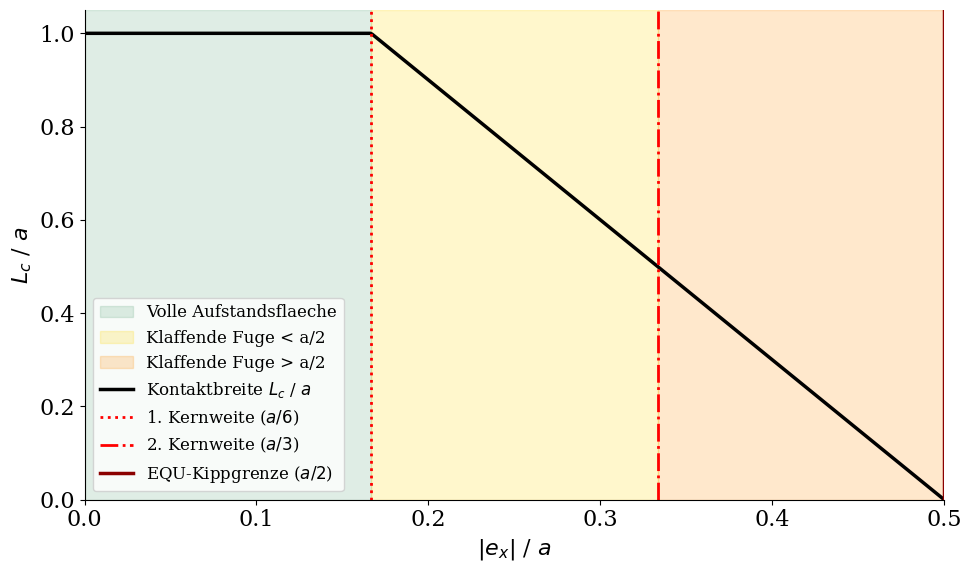

In [32]:
plot_kippgrenze_precompute()

In der folgenden interaktiven Darstellung lassen sich $V/(ab)$ und $e_x/a$ frei einstellen (auch ueber die Kippgrenze hinaus). Links ist das Fundament mit der Sohldruckverteilung skizziert (gruen: Kontakt, rot schraffiert: klaffende Fuge bzw. vollstaendiger Verlust des Kontakts), inklusive der 1./2. Kernweite und der Kippgrenze auf der Basislinie; rechts die zugehoerige Sohldruckverteilung $\sigma_0(x)$.

In [33]:
interactive_kippnachweis()

interactive(children=(IntSlider(value=100, description='$V$ / $ab$ / kPa', max=300, min=10, step=10, style=Sli…

## 2. Federmodell: starres Fundament auf zugfreien Einzelfedern

Bislang haben wir die Sohldruckverteilung aus der Annahme einer ebenen (linearen) Verteilung plus Gleichgewichtsbedingungen hergeleitet ("Spannungstrapezverfahren"). Wir zeigen nun, dass sich dieselbe Loesung ergibt, wenn man das Fundament stattdessen auf $N$ unabhaengigen, ausschliesslich **druckfesten** (zugfreien) **Bettungsfedern** lagert -- ein diskretes Winkler-Modell.

Wir diskretisieren die Fundamentbreite in $N$ Federn an den Stellen $\xi_i = -\tfrac12 + \left(i+\tfrac12\right)\Delta\xi$, $\Delta\xi = 1/N$. Jede Feder hat dieselbe Steifigkeit $k$ (Bettungsmodul $k_\text{s}$ mal Einflussbreite). Bleibt das Fundament -- wie bisher -- **starr**, dann liegt die Setzungslinie auf einer Ebene:

$$
    s(\xi) = s_0 + \varphi\,\xi \qquad \Rightarrow \qquad \sigma_i = k\big(s_0 + \varphi\,\xi_i\big) \quad \text{sofern } \sigma_i \geq 0
$$

Federn, fuer die sich rechnerisch $\sigma_i < 0$ (Zug) ergaebe, koennen keine Kraft uebertragen (**Kontaktbedingung**, $\sigma_i = 0$ statt Zug) und werden aus dem aktiven System entfernt. Fuer die verbleibenden aktiven Federn (Indexmenge $\mathcal{A}$) muessen Kraefte- und Momentengleichgewicht in diskreter Form erfuellt sein (Summen statt Integrale, vgl. die kontinuierliche Herleitung in [sohldruck.ipynb](sohldruck.ipynb)):

$$
    \sum_{i \in \mathcal{A}} \sigma_i\,\Delta\xi = \bar\sigma_0, \qquad \sum_{i \in \mathcal{A}} \sigma_i\,\xi_i\,\Delta\xi = \bar\sigma_0\,\frac{e_x}{a}
$$

Da beide Gleichungen in $s_0$ und $\varphi$ linear sind, laesst sich pro Iterationsschritt ein $2\times2$-System loesen. Die Loesung erfolgt **iterativ** (Active-Set-Verfahren):

1. Starte mit allen $N$ Federn aktiv.
2. Loese das $2\times2$-Gleichgewichtssystem fuer die Koeffizienten der (linearen) Sohldrucklinie.
3. Werden fuer Federn negative Spannungen (Zug) berechnet, deaktiviere diese Federn.
4. Wiederhole 2.-3., bis sich die aktive Menge nicht mehr aendert.

Bemerkenswert: Die Bettungsziffer $k$ (bzw. $k_\text{s}$) **kuerzt sich heraus** -- bei gleichfoermiger Bettung eines starren Koerpers haengt die Kontaktspannungsverteilung nur von $V$, $e_x$ und der Geometrie ab, nicht von der Steifigkeit der Federn. Das Ergebnis sollte daher (bei hinreichend feiner Diskretisierung) mit der kontinuierlichen Loesung aus Abschnitt 1 uebereinstimmen. Schrumpft die aktive Menge auf weniger als zwei Federn, kann kein Gleichgewicht mehr gefunden werden -- das entspricht numerisch dem Erreichen der Kippgrenze.

Mit dem Regler $N$ laesst sich die Diskretisierung veraendern und die Konvergenz der diskreten Loesung (gruene Balken) gegen die kontinuierliche Loesung (schwarze Kurve) beobachten. Abgehobene (zugfreie) Federn werden gestrichelt/grau dargestellt, aktive (gedrueckte) Federn gruen -- die Strichstaerke skaliert mit der uebertragenen Kraft.

In [34]:
interactive_federmodell()

interactive(children=(IntSlider(value=100, description='$V$ / $ab$ / kPa', max=300, min=10, step=10, style=Sli…

## Fazit

Beide Modelle -- die starre Spannungstrapez-/Dreieckloesung und das diskrete Federmodell mit Zugausschluss -- liefern dieselbe physikalische Grenze: Die Kontaktflaeche schrumpft mit wachsender Exzentrizitaet monoton, bis sie bei $|e_x| = a/2$ verschwindet. Dort ist der EQU-Grenzzustand "Verlust der Lagesicherheit durch Kippen" erreicht. Das Federmodell macht dabei anschaulich sichtbar, *warum* Zugspannungen in der Sohlfuge ausgeschlossen werden muessen: einzelne Federn heben schlicht ab, sobald ihre rechnerische Beanspruchung ins Negative liefe.

Fuer die Bemessungspraxis (EQU nach DIN EN 1997-1) ist zusaetzlich zu beachten:
- Die Nachweisfuehrung erfolgt mit **Bemessungswerten** der Einwirkungen (guenstige staendige Einwirkungen abgemindert, ungeguenstige erhoeht), wodurch sich eine Bemessungs-Exzentrizitaet $e_{x,d}$ ergibt, die mit $a/2$ zu vergleichen ist.
- In der Regel ist der Nachweis gegen **Grundbruch** (GEO-2) sowie gegen **Gleiten** deutlich vor Erreichen der geometrischen Kippgrenze massgebend.

## 3. Turmbeispiel: Kippstabilitaet in Abhaengigkeit von Neigung und Bettung

Wir betrachten nun einen konkreten Fall: einen **starren Turm** (z.B. Stahlbeton, Wichte $\gamma=25\,$kN/m³) mit rechteckigem Querschnitt, Breite $a$ (= Breite der Sohlfuge) und Hoehe $H$, gleichfoermiger Dichte (Schwerpunkt bei $z_\text{G}=H/2$). Anstatt die Exzentrizitaet $e_x$ direkt vorzugeben, fragen wir: **Ab welcher Neigung $\theta$ (Kippwinkel des Turms aus der Vertikalen) verliert der Turm die Standsicherheit** -- und zwar getrennt fuer starren Baugrund und fuer das Federmodell mit zugfreien Federn aus Abschnitt 2?

**Kinematik:** Neigt sich der (als starr angenommene) Turm um den Winkel $\theta$, so wandert der Schwerpunkt gegenueber der (mitgeneigten) Sohlflaeche horizontal um $z_\text{G}\sin\theta$ -- der klassische **P-Delta-Effekt**. Das Eigengewicht $V=\gamma a H$ wirkt also mit der Exzentrizitaet

$$
    e(\theta) = z_\text{G}\sin\theta
$$

Das ist exakt die Groesse, die wir in den Abschnitten 1 und 2 als *extern vorgegebene* Exzentrizitaet behandelt haben -- hier wird sie jedoch vom Turm **selbst erzeugt**. Die Fragestellung aendert sich dadurch grundlegend: Es geht nicht mehr um die Existenz einer Gleichgewichtslage (die gibt es rechnerisch fast immer, solange $|e(\theta)| < a/2$), sondern um deren **Stabilitaet** -- kehrt der Turm nach einer kleinen Stoerung in die Ausgangslage zurueck, oder waechst die Stoerung an?

### Starrer Baugrund: die klassische Kipp-("Wackelstein"-)Bedingung

Auf starrem Baugrund kann eine Neigung $\theta \ne 0$ nur dadurch entstehen, dass der Turm um eine seiner Sohlkanten **rotiert** (zwei starre Koerper beruehren sich nur entlang einer Linie). Solange die Schwerpunktprojektion noch innerhalb der Sohlflaeche liegt, erzeugt die Schwerkraft ein **rueckstellendes** Moment um die momentane Drehkante; sobald sie die Kante ueberschreitet, wird dieses Moment **kippend**. Die Grenze liegt dort, wo der Schwerpunkt exakt ueber der Kante steht:

$$
    \boxed{\theta_{\text{krit,starr}} = \arctan\left(\frac{a}{2 z_\text{G}}\right)}
$$

Dies ist die klassische Standsicherheitsbedingung starrer Koerper gegen Kippen (vgl. das "Rocking-Block"-Modell nach Housner) -- sie haengt **nicht** von der Masse/dem Gewicht des Turms ab (rein geometrisch), sondern nur vom Seitenverhaeltnis $a/H$.

### Federmodell: Stabilitaet statt reiner Gleichgewichtsfrage

Auf dem Federbett aus Abschnitt 2 existiert dagegen fuer *jeden* Winkel $\theta$ mit $z_\text{G}|\sin\theta| < a/2$ eine Gleichgewichtsverteilung der Sohlspannungen (unser Federmodell liefert sie ueber die Vertikalgleichgewichtsbedingung). Entscheidend ist aber, ob diese Gleichgewichtslage **stabil** ist: Stoeren wir den Turm um $\mathrm{d}\theta$, so waechst das destabilisierende Moment um

$$
    \mathrm{d}M_\text{dest} = \frac{\mathrm{d}}{\mathrm{d}\theta}\left[V z_\text{G}\sin\theta\right] \mathrm{d}\theta \approx V z_\text{G}\,\mathrm{d}\theta
$$

waehrend die Bettung ein zusaetzliches rueckstellendes Moment $\mathrm{d}M_\text{found} = k_\varphi(\theta)\,\mathrm{d}\theta$ mobilisiert, mit der **tangentialen Drehfedersteifigkeit** $k_\varphi(\theta)$ der (teilweise klaffenden) Bettung. Solange alle Federn im Kontakt bleiben (volle Aufstandsflaeche, $|e/a|\le 1/6$), ist die Bettung linear-elastisch und $k_\varphi$ konstant:

$$
    k_\varphi(0) = k_\text{s}\int_{-a/2}^{a/2}\xi^2\,\mathrm{d}\xi = \frac{k_\text{s}\,a^3}{12}
$$

**Stabilitaetskriterium bei $\theta=0$:** Der Turm ist infinitesimal stabil, wenn das Bettungs- das Kippmoment dominiert:

$$
    \boxed{k_\text{s} \geq k_{\text{s,krit}} = \frac{12\,V\,z_\text{G}}{a^3}}
$$

Ist $k_\text{s}$ kleiner, ist der Turm bereits bei $\theta=0$ instabil -- eine beliebig kleine Stoerung waechst an (klassische **Knick-/P-Delta-Instabilitaet** eines "invertierten Pendels" auf elastischer Bettung). Ist $k_\text{s}$ groesser, ist die aufrechte Lage lokal stabil; mit wachsendem $\theta$ nimmt die Kontaktflaeche jedoch progressiv ab (zugfreie Federn!), wodurch $k_\varphi(\theta)$ kontinuierlich bis auf null bei $\theta_{\text{krit,starr}}$ abfaellt. Da die Kippmoment-"Nachfrage" $Vz_\text{G}\sin\theta$ dagegen kaum abnimmt, ueberholt sie das verfuegbare Bettungsmoment bei einem **endlichen Winkel $\theta^\ast \le \theta_{\text{krit,starr}}$**: Ab $\theta^\ast$ existiert zwar rechnerisch noch eine (instabile) Gleichgewichtslage, sie ist aber nicht mehr erreichbar, der Turm kippt. Wie unten gezeigt, waechst $\theta^\ast$ mit $k_\text{s}$ dabei **stetig und monoton** von $0$ (bei $k_\text{s}=k_{\text{s,krit}}$) und naehert sich der starren Grenze $\theta_{\text{krit,starr}}$ nur asymptotisch -- ein "Sprung" auf die starre Loesung tritt bei keiner endlichen Steifigkeit ein, sie wird erst im Grenzwert $k_\text{s}\to\infty$ exakt erreicht.

In der folgenden interaktiven Darstellung koennen Turmgeometrie ($a$, $H$), die Bettungssteifigkeit relativ zum kritischen Wert ($k_\text{s}/k_{\text{s,krit}}$), ein Verfestigungs-/Entfestigungsexponent $n$ (siehe unten) sowie die aktuelle Neigung $\theta$ frei gewaehlt werden. Links: Turm und Bettung im Schema (aktive/abgehobene Federn gruen/grau, Lotlinie durch den Schwerpunkt gestrichelt). Rechts: destabilisierendes Moment $M_\text{dest}(\theta)$ (schwarz) vs. verfuegbares Bettungsmoment $M_\text{found}(\theta)$ (gruen); der Schnittpunkt markiert $\theta^\ast$ (orange), die starre geometrische Grenze $\theta_{\text{krit,starr}}$ ist rot markiert.

**Technischer Hinweis:** Sowohl die Federstauchung $s(\xi)=s_0+\xi\sin\theta$ als auch der Hebelarm der Sohlspannungen $\xi\cos\theta$ (fuer $M_\text{found}$) werden im Folgenden **exakt** ueber $\sin\theta$ bzw. $\cos\theta$ ausgewertet -- keine Kleinwinkelnaeherung ($\sin\theta\approx\theta$, $\cos\theta\approx1$). Das ist gerade bei diesem Beispiel wichtig, da wir uns bewusst bis nahe an die geometrisch grosse Kippgrenze $\theta_{\text{krit,starr}}$ (hier zweistellige Winkelgrade) heranbewegen. Einzig die Definition der linearisierten Anfangssteifigkeit $k_\varphi(0)$ bzw. $k_{\text{s,krit}}$ oben ist -- wie jede Tangentensteifigkeit -- eine Ableitung bei $\theta=0$ und dort ohnehin exakt (dort gilt $\sin\theta\approx\theta$ und $\cos\theta\approx1$ nur im Grenzwert, die Ableitung selbst ist unabhaengig davon korrekt).

In [ ]:
interactive_turm_kippen()

interactive(children=(FloatSlider(value=4.0, description='Turmbreite $a$ / m', max=8.0, min=2.0, step=0.5, sty…

### Einfluss von Ver-/Entfestigung der Bettung

Reale Boeden verhalten sich selten linear-elastisch. Wir ersetzen das lineare Federgesetz durch ein einfaches, monoton wachsendes Potenzgesetz

$$
    \sigma(s) = k_\text{s}\,s_\text{ref}\left(\frac{s}{s_\text{ref}}\right)^n \qquad (s\ge0,\ \text{sonst } \sigma=0)
$$

wobei $s_\text{ref}$ so gewaehlt ist, dass die Kurve unabhaengig von $n$ durch den Ausgangszustand unter Eigengewicht laeuft. Der Exponent $n$ steuert die **Tangentensteifigkeit am Betriebspunkt**, $\mathrm{d}\sigma/\mathrm{d}s\big|_{s_\text{ref}} = n\,k_\text{s}$:

- $n=1$: linear-elastische Bettung (Referenzfall oben).
- $n>1$: **Verfestigung** -- die Bettung wird bei weiterer Stauchung (auf der belasteten Seite, waehrend der Neigung) steifer als linear angenommen. Das erhoeht das verfuegbare Rueckstellmoment bei wachsendem $\theta$ und **verbessert** die Kippstabilitaet: Bereits eine kleinere nominelle Steifigkeit $k_\text{s}$ genuegt, um bis nahe an die geometrische Grenze $\theta_{\text{krit,starr}}$ stabil zu bleiben.
- $n<1$: **Entfestigung** -- die Bettung verliert bei weiterer Stauchung an Steifigkeit (typisch fuer sich einer Grundbruchlast naehernde, plastifizierende Boeden). Das verfuegbare Rueckstellmoment waechst langsamer als linear an, die Kippstabilitaet **verschlechtert** sich drastisch: Es wird eine deutlich hoehere nominelle Bettungssteifigkeit benoetigt, um ueberhaupt eine von null verschiedene stabile Neigung zu erreichen. Dieser Mechanismus -- fortschreitende Bodenerweichung unter der staerker belasteten Fundamentkante -- ist ein realistisches Modell fuer den fortschreitenden Verlust der Kippstabilitaet z.B. schlanker Tuerme oder Silos auf weichem/sensitivem Untergrund.

Die folgende (vorab berechnete) Darstellung fasst dies zusammen: die kritische Neigung $\theta^\ast$ als Funktion der (linear bezogenen, logarithmisch aufgetragenen) Bettungssteifigkeit $k_\text{s}/k_{\text{s,krit}}$, fuer Entfestigung, linares Verhalten und Verfestigung. Alle drei Kurven setzen exakt bei ihrem jeweiligen linearisierten Schwellenwert ($n\,k_\text{s}=k_{\text{s,krit}}$) mit $\theta^\ast=0$ ein, steigen dann steil aber **stetig und monoton** an und naehern sich der geometrischen Grenze $\theta_{\text{krit,starr}}$ mit wachsendem $k_\text{s}$ immer weiter an -- ohne sie bei endlicher Steifigkeit je exakt zu erreichen (vgl. die Konsistenzprobe unten). Deutlich sichtbar ist aber der grosse *quantitative* Unterschied: Bei gleicher (auf $k_{\text{s,krit}}$ bezogener) Steifigkeit erlaubt Verfestigung eine erheblich groessere Neigung als Entfestigung -- bzw. umgekehrt: um dieselbe Kippsicherheit zu erreichen, braucht eine entfestigende Bettung eine um Groessenordnungen hoehere nominelle Steifigkeit als eine verfestigende.

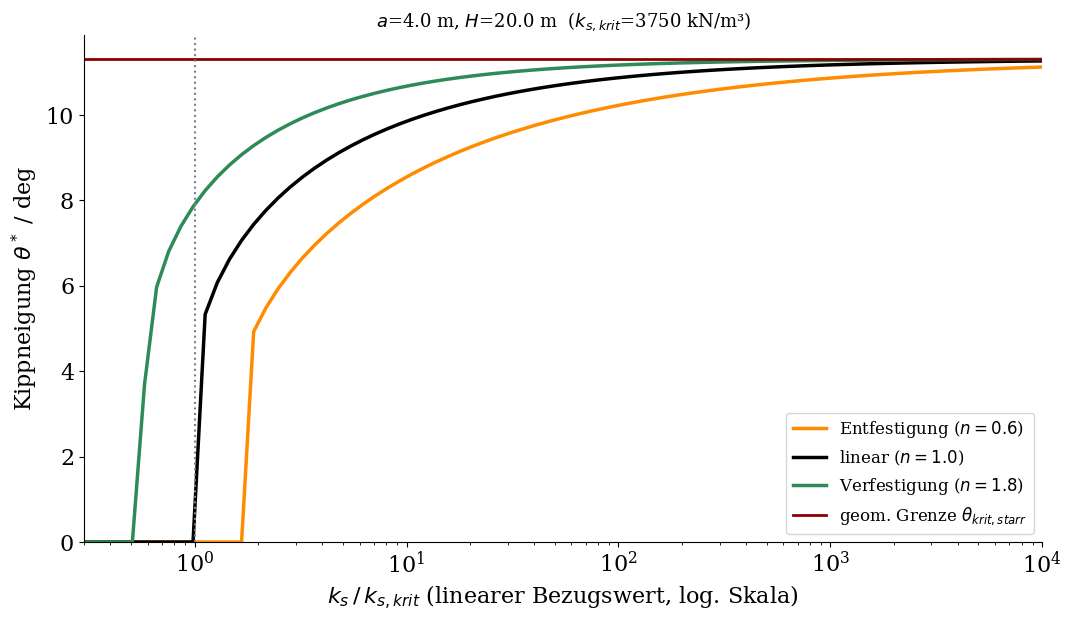

In [36]:
plot_kippschwelle_federsteifigkeit()

**Konsistenzprobe -- Grenzfall starrer Baugrund:** Fuer $k_\text{s}\to\infty$ muss unser Federmodell in die starre Wackelstein-Bedingung $\theta^\ast \to \theta_{\text{krit,starr}}=\arctan(a/2z_\text{G})$ uebergehen -- und genau das tut es, allerdings nur **asymptotisch**: Da die Kontaktbreite $L_\text{c}(\theta)$ unabhaengig von $k_\text{s}$ bei $\theta_{\text{krit,starr}}$ auf null zusammenschrumpft (vgl. Abschnitt 1), wird das "gefaehrliche" Winkelfenster, in dem die Bettung nicht mehr mithalten kann, mit steigendem $k_\text{s}$ immer schmaler -- numerisch bestaetigt ueber mehrere Groessenordnungen von $k_\text{s}$ (bei $k_\text{s}=10^8\,k_{\text{s,krit}}$ betraegt die Restabweichung von $\theta_{\text{krit,starr}}$ nur noch rund $4\cdot10^{-4}$ Grad, bei $k_\text{s}=10^4\,k_{\text{s,krit}}$ etwa $0{,}04$ Grad). Eine *exakte* Uebereinstimmung stellt sich streng genommen erst im Grenzwert ein, keine endliche Bettungssteifigkeit reicht ganz an die starre Loesung heran -- das ist konsistent mit der stetigen, monoton wachsenden $\theta^\ast(k_\text{s})$-Kurve oben, die sich der roten Linie annaehert, ohne sie je zu beruehren. Diese Grenzwertbildung ist kein Zufall: Die Bedingung $|e_x|=a/2$ aus dem Nachweis gegen Kippen fuer den starren Baugrund in Abschnitt 1 **ist** die Wackelstein-Bedingung -- beide beschreiben denselben geometrischen Grenzzustand (Resultierende/Lotlinie durch den Schwerpunkt erreicht die Fundamentkante), einmal ueber eine vorgegebene Exzentrizitaet, einmal ueber eine Neigung formuliert.

**Zusammenfassung Turmbeispiel:** Die geometrische Kippgrenze $\theta_{\text{krit,starr}}=\arctan(a/2z_\text{G})$ ist eine obere Schranke, die auf starrem Baugrund immer (und nur dort) tatsaechlich erreicht wird. Jede endliche, insbesondere entfestigende Bettung reduziert die real ertragbare Neigung teils erheblich -- die Bettungssteifigkeit (und ihr Verlauf mit der Belastung) ist damit ein ebenso wichtiger Kippstabilitaets-Parameter wie die reine Fundamentgeometrie.

## 4. Einordnung in die Stabilitaets- und Bifurkationstheorie

Das Turmbeispiel ist ein Spezialfall des allgemeinen Stabilitaetsproblems aus [stability_bifurcation.ipynb](stability_bifurcation.ipynb) (nach Bigoni): dort haelt eine Drehfeder $k_\text{r}$ ein Gelenk gegen ein destabilisierendes Moment, das eine (dort ueber die Axialfeder vermittelte, last- bzw. weggesteuerte) Kraft $F$ ueber den Hebelarm $l\sin\vartheta$ erzeugt -- ein klassisches P-Delta-Problem. Unser Turm hat exakt dieselbe Struktur:

| dort (Bigoni-Beispiel) | hier (Turm auf Bettung) |
|---|---|
| Drehwinkel $\vartheta$ | Neigung $\theta$ |
| lineare Drehfeder $k_\text{r}$ | (nichtlineare, zugfreie) Bettungsreaktion, $\mathrm{d}M_\text{found}/\mathrm{d}\theta = k_\varphi(\theta)$ |
| Kraft $F$ (Kontrollparameter, last- **oder** weggesteuert) | Eigengewicht $V$ (fest -- Kontrollparameter ist stattdessen $k_\text{s}$) |
| destabilisierendes Moment $Fl\sin\vartheta$ | destabilisierendes Moment $Vz_\text{G}\sin\theta$ |
| Stabilitaetsgrenze $\tilde{F}_\text{cr}=\tfrac{1\pm\sqrt{1-4\tilde{k}}}{2}$ | Stabilitaetsgrenze $k_\text{s,krit}=12Vz_\text{G}/a^3$ |

Wir uebertragen die dortige **energetische** Herangehensweise (totales Potential $\Pi$, erste Variation = Gleichgewicht, zweite Variation = Stabilitaet) direkt auf unseren Turm.

**Totales Potential:** Die im Boden gespeicherte (elastische) Energie ist die Arbeit, die die Bettungsreaktion beim Aufbringen der Neigung leistet, das Eigengewicht liefert ein Potential aus der Absenkung des Schwerpunkts um $z_\text{G}(1-\cos\theta)$:

$$
    \Pi(\theta) = \underbrace{\int_0^\theta M_\text{found}(\theta')\,\mathrm{d}\theta'}_{\text{el. Energie der Bettung}} \; \underbrace{-\, V z_\text{G}(1-\cos\theta)}_{\text{Potential des Eigengewichts}}
$$

Die erste Variation liefert genau unsere bisherige Gleichgewichtsbedingung, die zweite unser Stabilitaetskriterium:

$$
    \frac{\mathrm{d}\Pi}{\mathrm{d}\theta} = M_\text{found}(\theta) - Vz_\text{G}\sin\theta = M_\text{found}(\theta) - M_\text{dest}(\theta) \overset{!}{=} 0, \qquad
    \frac{\mathrm{d}^2\Pi}{\mathrm{d}\theta^2} = k_\varphi(\theta) - Vz_\text{G}\cos\theta
$$

Fuer die (immer vorhandene) triviale Loesung $\theta=0$ reproduziert die zweite Variation exakt unser fruehere Kriterium $k_\text{s} \gtrless k_{\text{s,krit}}$. Anschaulicher wird es im Energiebild: Fuer $k_\text{s}>k_{\text{s,krit}}$ ist $\theta=0$ ein **Potentialminimum** (Mulde, stabil); mit wachsendem $\theta$ steigt $\Pi$ zunaechst an, erreicht bei $\theta=\theta^\ast$ ein **Maximum** (die "Potentialschwelle") und faellt danach ab -- $\theta^\ast$ ist also nicht nur der Schnittpunkt zweier Momentenkurven, sondern der Kamm des Potentialbergs, über den der Turm "abrollt", sobald er ihn erreicht. Fuer $k_\text{s}<k_{\text{s,krit}}$ gibt es keine Mulde mehr -- $\theta=0$ ist von Anfang an ein Maximum.

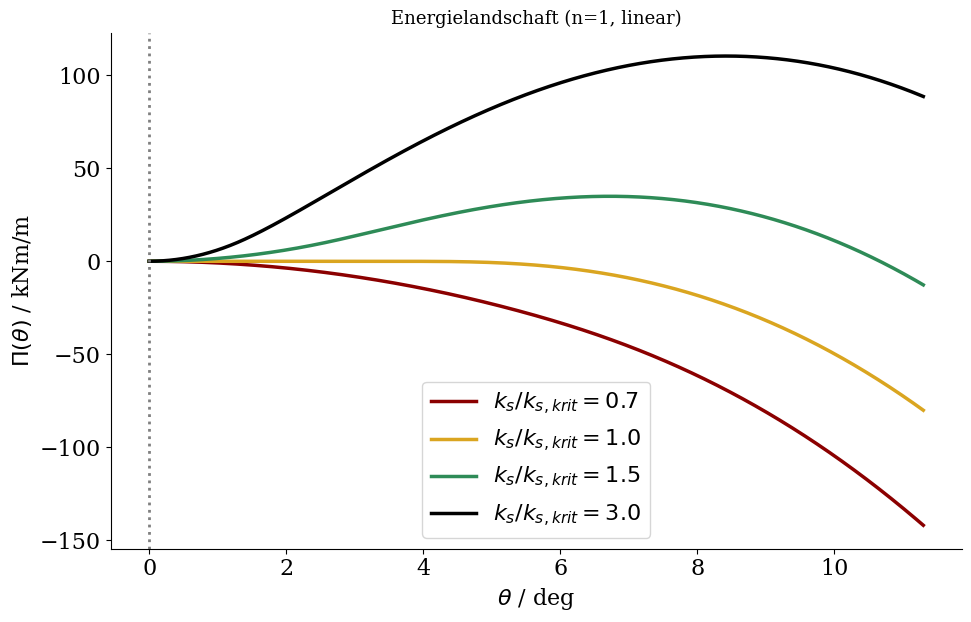

In [37]:
plot_energy_landscape()

**Stabilitaetskarte:** Wie im Referenzskript tragen wir das Vorzeichen von $\delta^2\Pi$ ueber der $(\theta, k_\text{s})$-Ebene auf (blau = stabil, rot = instabil). Die blaue "Mulde" reicht von $\theta=0$ bis zur Kurve $\theta^\ast(k_\text{s})$ aus Abschnitt 3 -- wir erkennen sie hier als die Grenzlinie zwischen den Vorzeichenbereichen wieder.

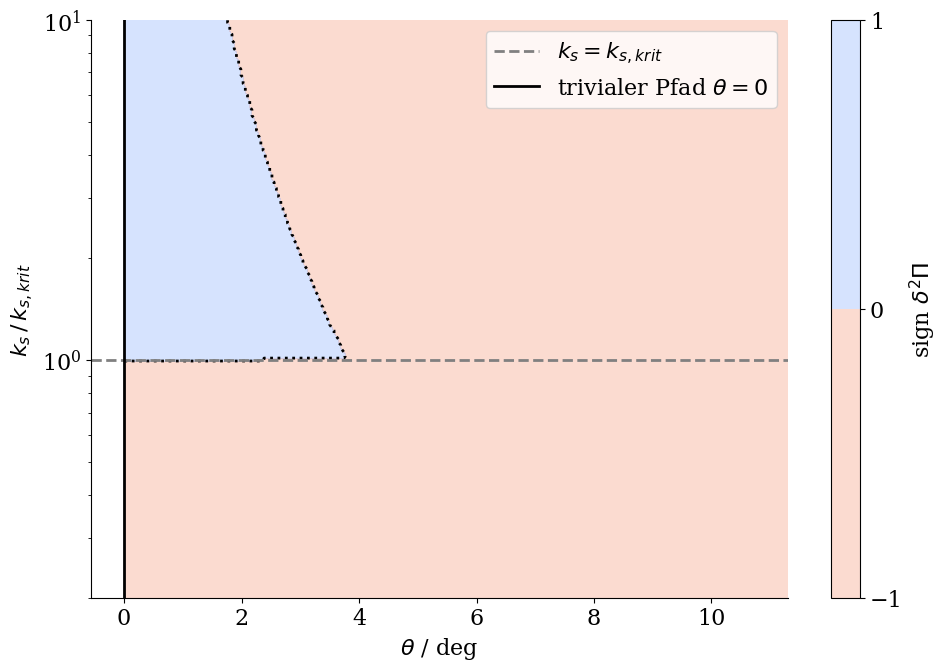

In [38]:
plot_stability_map()

**Ein wesentlicher Unterschied zum Referenzbeispiel:** Dort fuehrt die last- bzw. weggesteuerte Kraft $F$ zu einem $F^2\cos\vartheta\sin\vartheta$-Term, der bei grossen Winkeln wieder ein *zweites* Gleichgewicht liefert (die "stark gestauchten" Aeste der Bifurkationsdiagramme) -- die Struktur kann nach dem Durchschlagen also auf einem neuen, stabilen Ast landen. Bei unserem Turm ist die destabilisierende Grosse dagegen durch das (feste!) Eigengewicht $Vz_\text{G}\sin\theta$ bestimmt und **beschraenkt** ($\le Vz_\text{G}$), waehrend das Bettungsmoment mit fortschreitendem Kontaktverlust monoton gegen null geht. Es existiert daher -- fuer keinen der hier betrachteten Feder-Kennlinien ($n\in[0{,}05,\,8]$, numerisch ueberprueft) -- ein zweiter Schnittpunkt: Sobald der Turm die Potentialschwelle bei $\theta^\ast$ ueberschritten hat, gibt es keinen neuen stabilen Ast, auf dem er "landen" koennte -- er kippt vollstaendig. Diese Coulomb-artige, nach oben beschraenkte Belastung (statt einer mit $\vartheta$ mitwachsenden Kraft) ist der Grund, warum unser Turm ein reines **Stabilitaetsproblem des Gleichgewichtsverlusts** darstellt und keine reichhaltigere Bifurkationsstruktur mit sekundaeren, stabilen Nachbeul-Zustaenden wie im Referenzbeispiel zeigt.